In [57]:
'''
Import and load data set
'''

import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

X_train=pd.read_csv("../output/x_train.csv")
X_test=pd.read_csv("../output/x_test.csv")
y_train=pd.read_csv("../output/y_train.csv").squeeze()
y_test=pd.read_csv("../output/y_test.csv").squeeze()


In [58]:
'''
Create the Decision Tree model, train, and predict
'''

dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)


In [59]:
'''
Predict accuracy and f1 scores
'''

accuracy = accuracy_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred, average="weighted")

# Recall and Precision scores
precision = precision_score(y_test,y_pred,average="weighted", zero_division=0)

recall = recall_score(y_test,y_pred,average="weighted", zero_division=0)

#ROC-AUC
y_pred_proba = dt_model.predict_proba(X_test)

roc_auc = roc_auc_score(y_test,y_pred_proba,multi_class="ovr",average="weighted")


In [60]:
'''
Print model results
'''

print("Decision Tree Results")
print(f"Accuracy: {accuracy:.4f}")
print(f"Weighted F1-score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")


Decision Tree Results
Accuracy: 0.5551
Weighted F1-score: 0.5411
Precision: 0.5357
Recall: 0.5551
ROC-AUC: 0.7008


In [61]:
'''
Analyze most important features and print
'''

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": dt_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(feature_importance)



Feature Importance:
                 Feature  Importance
10               alcohol    0.395808
9              sulphates    0.170585
1       volatile acidity    0.113246
6   total sulfur dioxide    0.100810
7                density    0.052291
0          fixed acidity    0.043783
8                     pH    0.039047
3         residual sugar    0.038161
5    free sulfur dioxide    0.018667
4              chlorides    0.014941
2            citric acid    0.012662


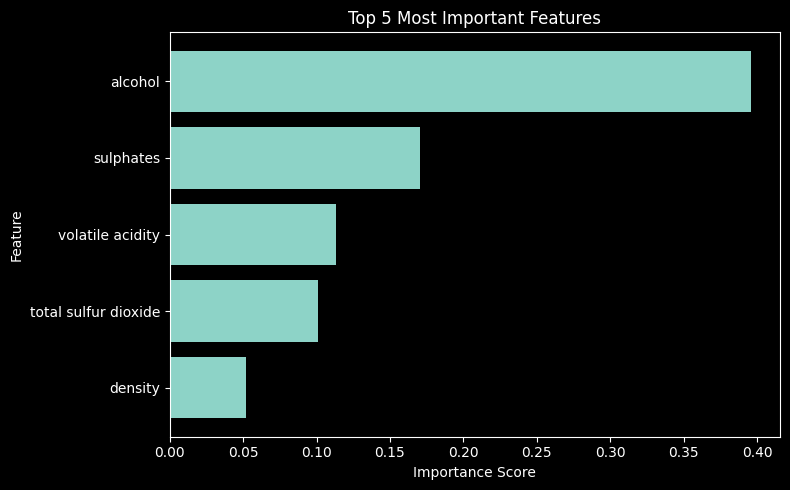

In [62]:
'''
Make graph of results
'''

top_features = feature_importance.head(5)

plt.figure(figsize=(8,5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 5 Most Important Features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()